In [1]:
import requests
import pandas as pd
from io import StringIO

# 1. Base API endpoint
url = (
    "https://ec.europa.eu/eurostat/api/dissemination/sdmx/3.0/data/"
    "dataflow/ESTAT/ISOC_EB_AI/1.0"
)

# 2. Filters sent with the request
params = {
    "format": "csvdata",
    "formatVersion": "2.0",
    "compress": "false"

}

# 3. Send GET request
response = requests.get(url, params=params)

# 4. Check whether it worked
print(response.status_code)

# 5. Turn returned CSV text into a DataFrame
ai_adoption_df = pd.read_csv(StringIO(response.text))

# 6. Inspect the result
ai_adoption_df.head()

200


,STRUCTURE,STRUCTURE_ID,freq,size_emp,nace_r2,indic_is,unit,geo,TIME_PERIOD,OBS_VALUE,OBS_FLAG,CONF_STATUS
0,dataflow,ESTAT:ISOC_EB_AI(1.0),A,0-9,C10-S951_X_K,E_AIX_CC1SIX_DA,PC_ENT,ES,2023,5.74,NaN,NaN
1,dataflow,ESTAT:ISOC_EB_AI(1.0),A,0-9,C10-S951_X_K,E_AIX_CC1SIX_DA,PC_ENT,ES,2024,5.66,NaN,NaN
2,dataflow,ESTAT:ISOC_EB_AI(1.0),A,0-9,C10-S951_X_K,E_AIX_CC1SIX_DA,PC_ENT,ES,2025,5.49,NaN,NaN
3,dataflow,ESTAT:ISOC_EB_AI(1.0),A,0-9,C10-S951_X_K,E_AIX_CC1SIX_DA,PC_ENT,PT,2023,13.36,NaN,NaN
4,dataflow,ESTAT:ISOC_EB_AI(1.0),A,0-9,C10-S951_X_K,E_AIX_CC1SIX_DA,PC_ENT_IUSE,ES,2023,6.88,NaN,NaN


In [2]:
ai_adoption_df

,STRUCTURE,STRUCTURE_ID,freq,size_emp,nace_r2,indic_is,unit,geo,TIME_PERIOD,OBS_VALUE,OBS_FLAG,CONF_STATUS
0,dataflow,ESTAT:ISOC_EB_AI(1.0),A,0-9,C10-S951_X_K,E_AIX_CC1SIX_DA,PC_ENT,ES,2023,5.74,NaN,NaN
1,dataflow,ESTAT:ISOC_EB_AI(1.0),A,0-9,C10-S951_X_K,E_AIX_CC1SIX_DA,PC_ENT,ES,2024,5.66,NaN,NaN
2,dataflow,ESTAT:ISOC_EB_AI(1.0),A,0-9,C10-S951_X_K,E_AIX_CC1SIX_DA,PC_ENT,ES,2025,5.49,NaN,NaN
3,dataflow,ESTAT:ISOC_EB_AI(1.0),A,0-9,C10-S951_X_K,E_AIX_CC1SIX_DA,PC_ENT,PT,2023,13.36,NaN,NaN
4,dataflow,ESTAT:ISOC_EB_AI(1.0),A,0-9,C10-S951_X_K,E_AIX_CC1SIX_DA,PC_ENT_IUSE,ES,2023,6.88,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
72522,dataflow,ESTAT:ISOC_EB_AI(1.0),A,GE250,C10-S951_X_K,E_DI3_VLO_AI_TANY,PC_ENT,SI,2023,0.00,NaN,NaN
72523,dataflow,ESTAT:ISOC_EB_AI(1.0),A,GE250,C10-S951_X_K,E_DI3_VLO_AI_TANY,PC_ENT,SI,2025,0.00,NaN,NaN
72524,dataflow,ESTAT:ISOC_EB_AI(1.0),A,GE250,C10-S951_X_K,E_DI3_VLO_AI_TANY,PC_ENT,SK,2023,0.18,NaN,NaN
72525,dataflow,ESTAT:ISOC_EB_AI(1.0),A,GE250,C10-S951_X_K,E_DI3_VLO_AI_TANY,PC_ENT,SK,2025,1.11,NaN,NaN


In [3]:
ai_adoption_df_clean=ai_adoption_df.copy()

In [4]:
ai_adoption_df.columns

Index(['STRUCTURE', 'STRUCTURE_ID', 'freq', 'size_emp', 'nace_r2', 'indic_is',
       'unit', 'geo', 'TIME_PERIOD', 'OBS_VALUE', 'OBS_FLAG', 'CONF_STATUS'],
      dtype='object')

In [5]:
ai_adoption_df.shape


(72527, 12)

In [6]:
ai_adoption_df_clean.columns = (
    ai_adoption_df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

In [7]:
ai_adoption_df_clean.columns

Index(['structure', 'structure_id', 'freq', 'size_emp', 'nace_r2', 'indic_is',
       'unit', 'geo', 'time_period', 'obs_value', 'obs_flag', 'conf_status'],
      dtype='object')

In [8]:
ai_adoption_df_clean_dropped = ai_adoption_df_clean.drop(
    columns=["structure", "structure_id"]
)

In [9]:
columns_to_check = [
    "freq",
    "size_emp",
    "nace_r2",
    "indic_is",
    "unit"
]

for column in columns_to_check:
    print(f"\n--- {column} ---")
    print(ai_adoption_df_clean_dropped[column].value_counts())


--- freq ---
freq
A    72527
Name: count, dtype: int64

--- size_emp ---
size_emp
10-249    13988
50-249    13988
GE10      13988
GE250     13987
10-49     13979
2-9        1286
0-9         912
0_1         399
Name: count, dtype: int64

--- nace_r2 ---
nace_r2
C10-S951_X_K    72527
Name: count, dtype: int64

--- indic_is ---
indic_is
E_AI_PITS          2146
E_AI_PPP           2146
E_AI_PMS           2146
E_AI_PLOG          2146
E_AI_BDDT          1983
                   ... 
E_AI_BIAS_ARDY      212
E_AI_BIAS_AMOWN     209
E_AI_BIAS_AOS       209
E_AI_BIAS_ADOWN     209
E_AI_PDI            142
Name: count, Length: 63, dtype: int64

--- unit ---
unit
PC_ENT            28062
PC_ENT_IUSE       26185
PC_ENT_AI_TANY     9464
PC_ENT_AI_TX       4454
PC_ENT_AI_EC       3945
PC_ENT_AI_PDI       417
Name: count, dtype: int64


In [10]:
ai_adoption_df_clean_dropped[
    ai_adoption_df_clean_dropped["indic_is"] == "E_AI_TANY"
][["size_emp", "unit"]].value_counts()

size_emp  unit       
10-49     PC_ENT_IUSE    140
          PC_ENT         140
10-249    PC_ENT_IUSE    140
          PC_ENT         140
GE10      PC_ENT         140
          PC_ENT_IUSE    140
50-249    PC_ENT         140
          PC_ENT_IUSE    140
GE250     PC_ENT         140
          PC_ENT_IUSE    140
2-9       PC_ENT          12
          PC_ENT_IUSE     12
0-9       PC_ENT           9
          PC_ENT_IUSE      9
0_1       PC_ENT           5
          PC_ENT_IUSE      5
Name: count, dtype: int64

In [11]:
ai_adoption_project = ai_adoption_df_clean_dropped[
    (ai_adoption_df_clean_dropped["size_emp"] == "GE10")
    & (ai_adoption_df_clean_dropped["indic_is"] == "E_AI_TANY")
    & (ai_adoption_df_clean_dropped["unit"] == "PC_ENT")
].copy()

In [12]:
ai_adoption_final = ai_adoption_project[
    ["geo", "time_period", "obs_value"]
].rename(
    columns={
        "geo": "country_code",
        "time_period": "year",
        "obs_value": "ai_adoption_pct"
    }
)

In [13]:
ai_adoption_final

,country_code,year,ai_adoption_pct
55148,AL,2021,3.67
55149,AL,2024,8.91
55150,AL,2025,8.99
55151,AT,2021,8.83
55152,AT,2023,10.79
...,...,...,...
55283,SK,2025,18.00
55284,TR,2021,2.69
55285,TR,2023,5.51
55286,TR,2024,4.42


In [14]:
ai_adoption_final.groupby("country_code")["ai_adoption_pct"].mean()

country_code
AL            7.1900
AT           17.4600
BA            6.1375
BE           20.8450
BG            5.4825
CY            6.1075
CZ            9.8050
DE           16.9575
DK           27.1675
EA           13.2400
EE           11.3125
EL            6.3325
ES           12.1075
EU27_2020    12.2850
FI           23.2700
FR           10.1550
HR           10.8950
HU            6.1100
IE           12.6075
IT            8.9550
LT            9.8425
LU           21.1975
LV            7.3225
ME            6.7275
MK               NaN
MT           15.5350
NL           20.8675
NO           17.4125
PL            5.1975
PT            8.8075
RO            2.7925
RS            4.9475
SE           20.1050
SI           16.4000
SK           10.2525
TR            5.0075
Name: ai_adoption_pct, dtype: float64

In [15]:
ai_adoption_by_year = (
    ai_adoption_final
    .groupby(["country_code", "year"])["ai_adoption_pct"]
    .mean()
    .reset_index()
)

In [16]:
exclude_codes = ["EA", "EU27_2020"]

ai_adoption_countries = ai_adoption_final[
    ~ai_adoption_final["country_code"].isin(exclude_codes)
].copy()

In [17]:
ai_adoption_by_year["country_code"].unique()

array(['AL', 'AT', 'BA', 'BE', 'BG', 'CY', 'CZ', 'DE', 'DK', 'EA', 'EE',
       'EL', 'ES', 'EU27_2020', 'FI', 'FR', 'HR', 'HU', 'IE', 'IT', 'LT',
       'LU', 'LV', 'ME', 'MK', 'MT', 'NL', 'NO', 'PL', 'PT', 'RO', 'RS',
       'SE', 'SI', 'SK', 'TR'], dtype=object)

In [18]:
ai_2024 = ai_adoption_countries[
    ai_adoption_countries["year"] == 2024
].sort_values("ai_adoption_pct", ascending=False)

In [19]:
country_names = {
    "AL": "Albania",
    "AT": "Austria",
    "BA": "Bosnia and Herzegovina",
    "BE": "Belgium",
    "BG": "Bulgaria",
    "CY": "Cyprus",
    "CZ": "Czechia",
    "DE": "Germany",
    "DK": "Denmark",
    "EE": "Estonia",
    "EL": "Greece",
    "ES": "Spain",
    "FI": "Finland",
    "FR": "France",
    "HR": "Croatia",
    "HU": "Hungary",
    "IE": "Ireland",
    "IT": "Italy",
    "LT": "Lithuania",
    "LU": "Luxembourg",
    "LV": "Latvia",
    "ME": "Montenegro",
    "MK": "North Macedonia",
    "MT": "Malta",
    "NL": "Netherlands",
    "NO": "Norway",
    "PL": "Poland",
    "PT": "Portugal",
    "RO": "Romania",
    "RS": "Serbia",
    "SE": "Sweden",
    "SI": "Slovenia",
    "SK": "Slovakia",
    "TR": "Türkiye"
}

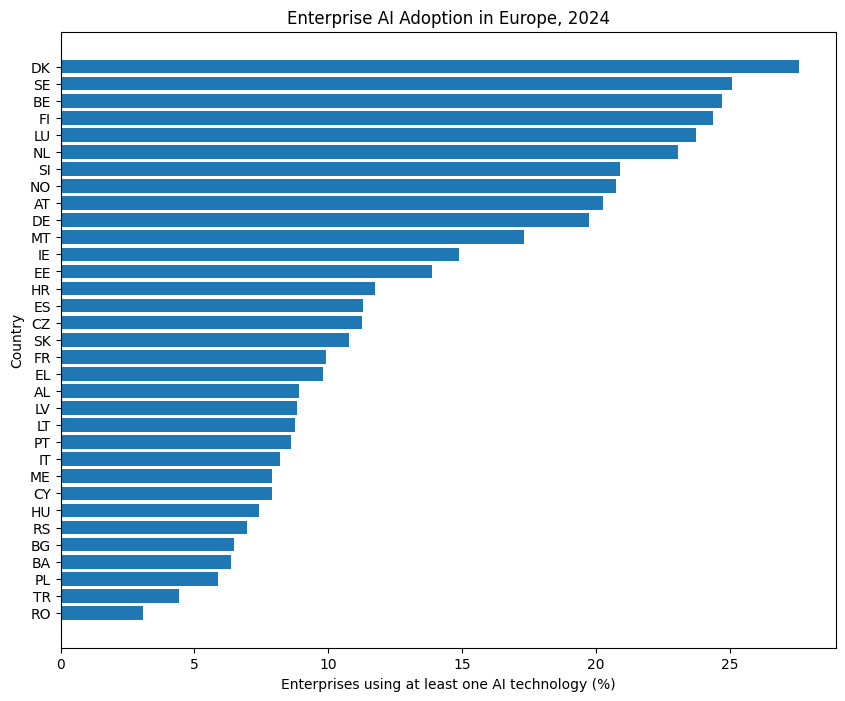

In [28]:

plt.figure(figsize=(10, 8))

plt.barh(
    ai_2024["country_code"],
    ai_2024["ai_adoption_pct"]
)

plt.xlabel("Enterprises using at least one AI technology (%)")
plt.ylabel("Country")
plt.title("Enterprise AI Adoption in Europe, 2024")

plt.gca().invert_yaxis()
plt.show()

In [ ]:
ai_adoption_by_year["year"].value_counts()

year
2021    36
2024    35
2025    35
2023    34
Name: count, dtype: int64

In [ ]:
ai_adoption_project

,freq,size_emp,nace_r2,indic_is,unit,geo,time_period,obs_value,obs_flag,conf_status
55148,A,GE10,C10-S951_X_K,E_AI_TANY,PC_ENT,AL,2021,3.67,NaN,NaN
55149,A,GE10,C10-S951_X_K,E_AI_TANY,PC_ENT,AL,2024,8.91,NaN,NaN
55150,A,GE10,C10-S951_X_K,E_AI_TANY,PC_ENT,AL,2025,8.99,NaN,NaN
55151,A,GE10,C10-S951_X_K,E_AI_TANY,PC_ENT,AT,2021,8.83,NaN,NaN
55152,A,GE10,C10-S951_X_K,E_AI_TANY,PC_ENT,AT,2023,10.79,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
55283,A,GE10,C10-S951_X_K,E_AI_TANY,PC_ENT,SK,2025,18.00,NaN,NaN
55284,A,GE10,C10-S951_X_K,E_AI_TANY,PC_ENT,TR,2021,2.69,NaN,NaN
55285,A,GE10,C10-S951_X_K,E_AI_TANY,PC_ENT,TR,2023,5.51,NaN,NaN
55286,A,GE10,C10-S951_X_K,E_AI_TANY,PC_ENT,TR,2024,4.42,NaN,NaN


In [ ]:
ai_adoption_final["ai_adoption_pct"].isnull().sum()

np.int64(1)

In [ ]:
ai_adoption_final = ai_adoption_final.dropna(
    subset=["ai_adoption_pct"])

In [ ]:
ai_adoption_final

,country_code,year,ai_adoption_pct
55148,AL,2021,3.67
55149,AL,2024,8.91
55150,AL,2025,8.99
55151,AT,2021,8.83
55152,AT,2023,10.79
...,...,...,...
55283,SK,2025,18.00
55284,TR,2021,2.69
55285,TR,2023,5.51
55286,TR,2024,4.42


# Day 3 EDA

In [58]:
# Load the dataset
import pandas as pd

# Load datasets
emissions = pd.read_csv(
    "https://github.com/Orgo4ever/data-wrangling-project/blob/main/clean_eurostat_power_sector_emissions.csv?raw=true"
)

ai_adoption = pd.read_csv(
    "https://github.com/Orgo4ever/data-wrangling-project/blob/main/ai_adoption_cleaned.csv?raw=true"
)

renewable = pd.read_csv(
    "https://github.com/Orgo4ever/data-wrangling-project/blob/main/cleaned_renewable_energy.csv?raw=true"
)

datacenter = pd.read_csv(
    "https://github.com/Orgo4ever/data-wrangling-project/blob/main/eu_facilities_cleaned.csv?raw=true"
)

# Make sure geo and year have matching formats
for df in [emissions_subset, renewable_subset, ai_subset]:
    df["geo"] = df["geo"].astype(str).str.strip().str.upper()
    df["year"] = pd.to_numeric(df["year"], errors="coerce")

# Keep one row per country-year in each dataset
emissions_subset = (
    emissions_subset
    .groupby(["geo", "year"], as_index=False)["emissions"]
    .mean()
)

renewable_subset = (
    renewable_subset
    .groupby(["geo", "year"], as_index=False)["renewable_energy_share"]
    .mean()
)

ai_subset = (
    ai_subset
    .groupby(["geo", "year"], as_index=False)["ai_adoption_pct"]
    .mean()
)

# Start with AI adoption so all AI years, including 2025, are kept
grouped_df = (
    ai_subset
    .merge(
        renewable_subset,
        on=["geo", "year"],
        how="left"
    )
    .merge(
        emissions_subset,
        on=["geo", "year"],
        how="left"
    )
)

# Add country names
grouped_df["country_name"] = grouped_df["geo"].map(country_names)

# Sort and reset index
grouped_df = (
    grouped_df
    .sort_values(["geo", "year"])
    .reset_index(drop=True)
)

# Check whether 2025 is included
print("Latest year in AI dataset:", ai_subset["year"].max())
print("Latest year in grouped dataframe:", grouped_df["year"].max())

print(grouped_df.tail())

Latest year in AI dataset: 2025
Latest year in grouped dataframe: 2025
    geo  year  ai_adoption_pct  renewable_energy_share     emissions  \
126  SK  2025            18.00                     NaN           NaN   
127  TR  2021             2.69                     NaN  79097.198180   
128  TR  2023             5.51                     NaN  76613.496960   
129  TR  2024             4.42                     NaN  80135.840785   
130  TR  2025             7.41                     NaN           NaN   

    country_name  
126     Slovakia  
127      Türkiye  
128      Türkiye  
129      Türkiye  
130      Türkiye  


In [60]:
# Select relevant columns
emissions_subset = emissions[["geo", "year", "emissions"]].copy()

renewable_subset = renewable[[
    "geo",
    "year",
    "renewable_energy_share"
]].copy()

ai_subset = ai_adoption[[
    "country_code",
    "year",
    "ai_adoption_pct"
]].rename(columns={"country_code": "geo"}).copy()

# Make country codes and years consistent before merging
for df in [emissions_subset, renewable_subset, ai_subset]:
    df["geo"] = (
        df["geo"]
        .astype(str)
        .str.strip()
        .str.upper()
    )

    df["year"] = pd.to_numeric(df["year"], errors="coerce")

# Make sure there is only one row per country per year
emissions_subset = (
    emissions_subset
    .groupby(["geo", "year"], as_index=False)["emissions"]
    .mean()
)

renewable_subset = (
    renewable_subset
    .groupby(["geo", "year"], as_index=False)["renewable_energy_share"]
    .mean()
)

ai_subset = (
    ai_subset
    .groupby(["geo", "year"], as_index=False)["ai_adoption_pct"]
    .mean()
)

# Start with AI adoption so its years, including 2025, are preserved
grouped_df = (
    ai_subset
    .merge(
        renewable_subset,
        on=["geo", "year"],
        how="left"
    )
    .merge(
        emissions_subset,
        on=["geo", "year"],
        how="left"
    )
)

# Add full country names if country_names dictionary already exists
grouped_df["country_name"] = grouped_df["geo"].map(country_names)

# Sort the finished dataframe
grouped_df = (
    grouped_df
    .sort_values(["geo", "year"])
    .reset_index(drop=True)
)



In [61]:
grouped_df["year"].unique()

array([2021, 2024, 2025, 2023])

In [25]:
import pandas as pd

ai_clean = (
    ai_adoption
    .groupby(["country_code", "year"], as_index=False)
    .agg({"ai_adoption_pct": "mean"})
    .rename(columns={"country_code": "geo"})
)

latest_year = ai_clean["year"].max()

top10 = (
    ai_clean[ai_clean["year"] == latest_year]
    .sort_values("ai_adoption_pct", ascending=False)
    .head(10)
)

print(top10)

    geo  year  ai_adoption_pct
34   DK  2025            42.03
50   FI  2025            37.82
118  SE  2025            35.04
14   BE  2025            34.54
78   LU  2025            33.61
94   NL  2025            33.21
6    AT  2025            29.95
98   NO  2025            28.89
30   DE  2025            25.97
38   EE  2025            23.40


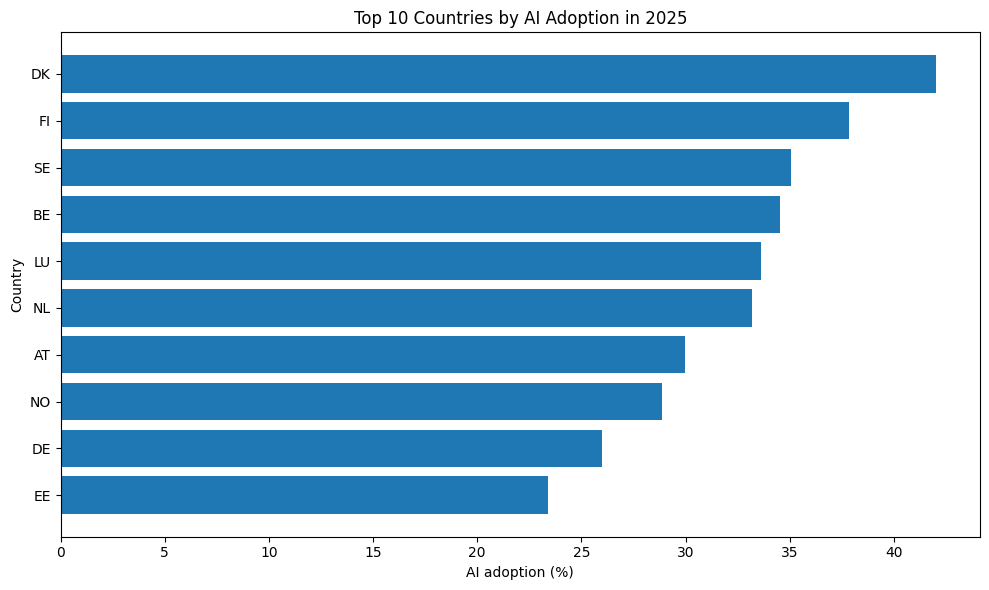

In [62]:
import matplotlib.pyplot as plt

# Sort so the highest-adoption country appears at the top
top10_plot = top10.sort_values("ai_adoption_pct", ascending=True)

plt.figure(figsize=(10, 6))

plt.barh(
    top10_plot["geo"],
    top10_plot["ai_adoption_pct"]
)

plt.title(f"Top 10 Countries by AI Adoption in {latest_year}")
plt.xlabel("AI adoption (%)")
plt.ylabel("Country")

plt.tight_layout()
plt.show()

In [63]:
facilities_by_country = (
    datacenter
    .groupby("geo")
    .size()
    .reset_index(name="facility_count")
)

In [73]:
# Remove any facility-count columns from earlier attempts
grouped_df = grouped_df.drop(
    columns=["facility_count", "facility_count_x", "facility_count_y"],
    errors="ignore"
).copy()

# Ensure geo codes match
grouped_df["geo"] = (
    grouped_df["geo"]
    .astype("string")
    .str.strip()
    .str.upper()
)

datacenter["geo"] = (
    datacenter["geo"]
    .astype("string")
    .str.strip()
    .str.upper()
)

# One facility count per country
facilities_by_country = (
    datacenter
    .dropna(subset=["geo"])
    .groupby("geo", as_index=False)
    .size()
    .rename(columns={"size": "facility_count"})
)

# This confirms there is only one row per geo in the facilities table
print("Duplicate countries in facilities table:",
      facilities_by_country["geo"].duplicated().sum())

# Merge: many country-year rows in grouped_df -> one country row in facilities_by_country
grouped_df = grouped_df.merge(
    facilities_by_country,
    on="geo",
    how="left",
    validate="m:1"
)

grouped_df["datacenters"] = (
    grouped_df["facility_count"]
    .fillna(0)
    .astype(int)
)

print(grouped_df.head())

Duplicate countries in facilities table: 0
  geo  year  ai_adoption_pct  renewable_energy_share    emissions  \
0  AL  2021             3.67                  41.389          NaN   
1  AL  2024             8.91                  43.111          NaN   
2  AL  2025             8.99                     NaN          NaN   
3  AT  2021             8.83                  34.643  4289.129845   
4  AT  2023            10.79                  41.600  3595.912320   

  country_name  datacenters  facility_count  
0      Albania            0             NaN  
1      Albania            0             NaN  
2      Albania            0             NaN  
3      Austria           56            56.0  
4      Austria           56            56.0  


In [74]:
grouped_df

,geo,year,ai_adoption_pct,renewable_energy_share,emissions,country_name,datacenters,facility_count
0,AL,2021,3.67,41.389,NaN,Albania,0,NaN
1,AL,2024,8.91,43.111,NaN,Albania,0,NaN
2,AL,2025,8.99,NaN,NaN,Albania,0,NaN
3,AT,2021,8.83,34.643,4289.129845,Austria,56,56.0
4,AT,2023,10.79,41.600,3595.912320,Austria,56,56.0
...,...,...,...,...,...,...,...,...
126,SK,2025,18.00,NaN,NaN,Slovakia,6,6.0
127,TR,2021,2.69,NaN,79097.198180,Türkiye,0,NaN
128,TR,2023,5.51,NaN,76613.496960,Türkiye,0,NaN
129,TR,2024,4.42,NaN,80135.840785,Türkiye,0,NaN


In [43]:
grouped_df

,geo,year,emissions,renewable_energy_share,ai_adoption_pct,facility_count
0,AT,2015,10.33398,33.497,NaN,56
1,AT,2016,10.11920,33.370,NaN,56
2,AT,2017,10.73059,33.136,NaN,56
3,AT,2018,9.88490,33.784,NaN,56
4,AT,2019,9.92108,33.755,NaN,56
...,...,...,...,...,...,...
635,TR,2020,141054.20000,NaN,NaN,0
636,TR,2021,158036.36000,NaN,2.69,0
637,TR,2022,154784.03000,NaN,NaN,0
638,TR,2023,153073.92000,NaN,5.51,0


In [75]:
grouped_df

,geo,year,ai_adoption_pct,renewable_energy_share,emissions,country_name,datacenters,facility_count
0,AL,2021,3.67,41.389,NaN,Albania,0,NaN
1,AL,2024,8.91,43.111,NaN,Albania,0,NaN
2,AL,2025,8.99,NaN,NaN,Albania,0,NaN
3,AT,2021,8.83,34.643,4289.129845,Austria,56,56.0
4,AT,2023,10.79,41.600,3595.912320,Austria,56,56.0
...,...,...,...,...,...,...,...,...
126,SK,2025,18.00,NaN,NaN,Slovakia,6,6.0
127,TR,2021,2.69,NaN,79097.198180,Türkiye,0,NaN
128,TR,2023,5.51,NaN,76613.496960,Türkiye,0,NaN
129,TR,2024,4.42,NaN,80135.840785,Türkiye,0,NaN


In [77]:
grouped_df.columns

Index(['geo', 'year', 'ai_adoption_pct', 'renewable_energy_share', 'emissions',
       'country_name', 'datacenters', 'facility_count'],
      dtype='object')

In [78]:
grouped_df = grouped_df.drop(columns="facility_count")

In [79]:
grouped_df

,geo,year,ai_adoption_pct,renewable_energy_share,emissions,country_name,datacenters
0,AL,2021,3.67,41.389,NaN,Albania,0
1,AL,2024,8.91,43.111,NaN,Albania,0
2,AL,2025,8.99,NaN,NaN,Albania,0
3,AT,2021,8.83,34.643,4289.129845,Austria,56
4,AT,2023,10.79,41.600,3595.912320,Austria,56
...,...,...,...,...,...,...,...
126,SK,2025,18.00,NaN,NaN,Slovakia,6
127,TR,2021,2.69,NaN,79097.198180,Türkiye,0
128,TR,2023,5.51,NaN,76613.496960,Türkiye,0
129,TR,2024,4.42,NaN,80135.840785,Türkiye,0


In [80]:
grouped_df.to_csv("merged_data.csv", index=False)

# Task 4 AI and Carbon Dioxide Emissions

In [81]:
# Part 4: keep only complete country-year observations
part4_df = grouped_df[[
    "geo",
    "country_name",
    "year",
    "ai_adoption_pct",
    "renewable_energy_share",
    "emissions"
]].copy()

# Remove rows missing any of the three variables needed for this analysis
part4_df = part4_df.dropna(
    subset=[
        "ai_adoption_pct",
        "renewable_energy_share",
        "emissions"
    ]
)

# Find the latest year with complete data
latest_complete_year = int(part4_df["year"].max())

# Keep only that year and ensure one row per country
part4_latest = (
    part4_df[part4_df["year"] == latest_complete_year]
    .groupby(["geo", "country_name"], as_index=False)
    .agg({
        "ai_adoption_pct": "mean",
        "renewable_energy_share": "mean",
        "emissions": "mean"
    })
)

print("Year used for Part 4:", latest_complete_year)
print("Number of countries:", part4_latest.shape[0])

part4_latest.head()

Year used for Part 4: 2024
Number of countries: 28


,geo,country_name,ai_adoption_pct,renewable_energy_share,emissions
0,AT,Austria,20.27,42.951,3577.318745
1,BE,Belgium,24.71,14.336,7349.221880
2,BG,Bulgaria,6.47,23.210,6388.932550
3,CY,Cyprus,7.90,20.844,1609.332725
4,CZ,Czechia,11.26,19.211,15863.437590


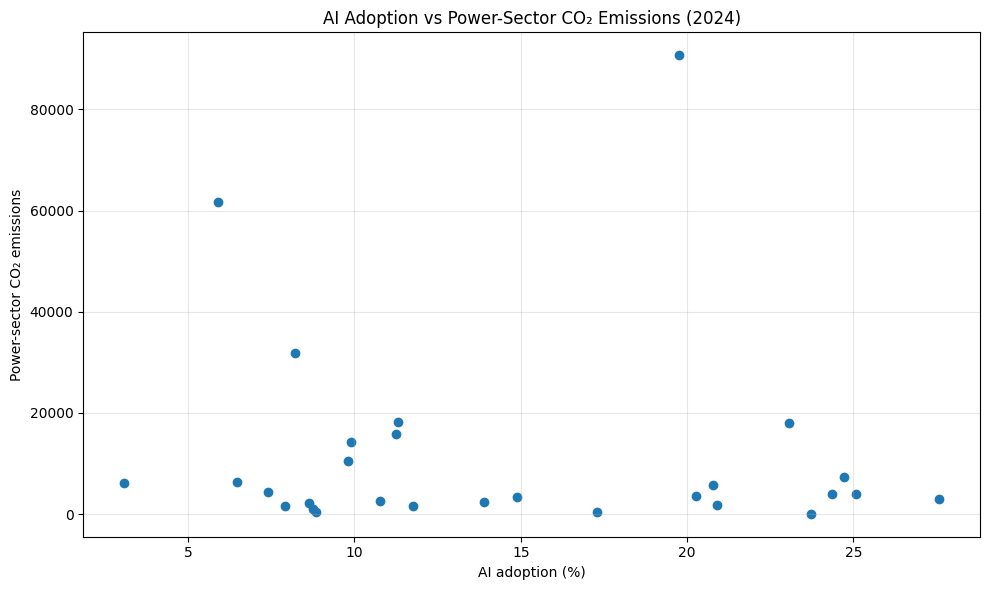

In [82]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.scatter(
    part4_latest["ai_adoption_pct"],
    part4_latest["emissions"]
)

plt.title(f"AI Adoption vs Power-Sector CO₂ Emissions ({latest_complete_year})")
plt.xlabel("AI adoption (%)")
plt.ylabel("Power-sector CO₂ emissions")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

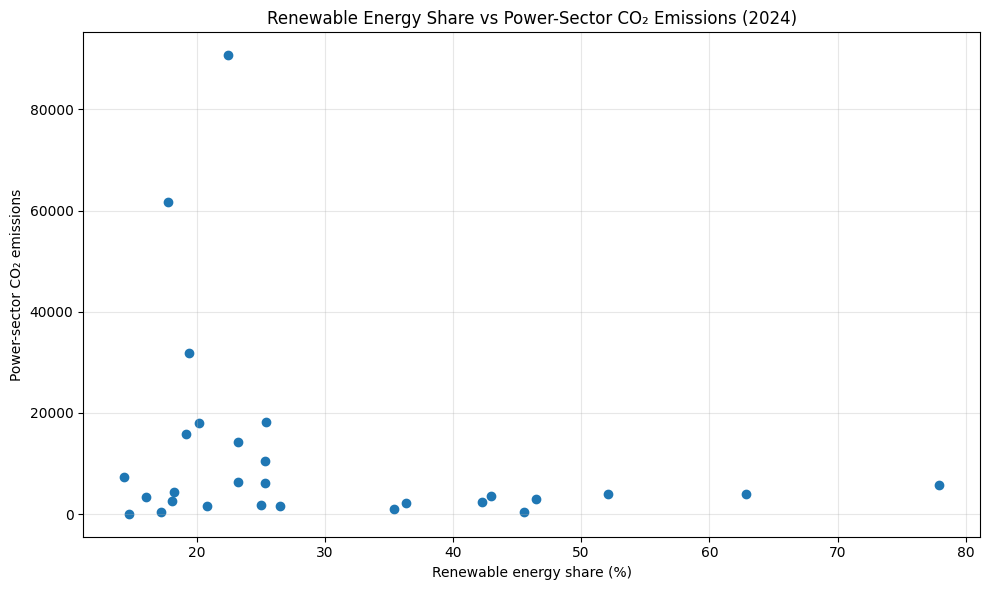

In [83]:
plt.figure(figsize=(10, 6))

plt.scatter(
    part4_latest["renewable_energy_share"],
    part4_latest["emissions"]
)

plt.title(f"Renewable Energy Share vs Power-Sector CO₂ Emissions ({latest_complete_year})")
plt.xlabel("Renewable energy share (%)")
plt.ylabel("Power-sector CO₂ emissions")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [84]:
ai_emissions_corr = part4_latest["ai_adoption_pct"].corr(
    part4_latest["emissions"]
)

renewable_emissions_corr = part4_latest["renewable_energy_share"].corr(
    part4_latest["emissions"]
)

print("Correlation: AI adoption vs emissions =", round(ai_emissions_corr, 3))
print("Correlation: Renewable energy vs emissions =", round(renewable_emissions_corr, 3))

Correlation: AI adoption vs emissions = -0.068
Correlation: Renewable energy vs emissions = -0.234


# 5   Sustainability Matrix

In [85]:
import numpy as np

# Create a separate dataframe for Part 5
matrix_df = part4_latest.copy()

# Calculate the middle value for each variable
ai_median = matrix_df["ai_adoption_pct"].median()
renewable_median = matrix_df["renewable_energy_share"].median()

print("AI adoption median:", round(ai_median, 2))
print("Renewable energy median:", round(renewable_median, 2))

# Create the four sustainability categories
conditions = [
    (matrix_df["ai_adoption_pct"] >= ai_median) &
    (matrix_df["renewable_energy_share"] >= renewable_median),

    (matrix_df["ai_adoption_pct"] >= ai_median) &
    (matrix_df["renewable_energy_share"] < renewable_median),

    (matrix_df["ai_adoption_pct"] < ai_median) &
    (matrix_df["renewable_energy_share"] >= renewable_median),

    (matrix_df["ai_adoption_pct"] < ai_median) &
    (matrix_df["renewable_energy_share"] < renewable_median)
]

categories = [
    "Sustainable AI Leaders",
    "Environmental Risk",
    "Green Potential",
    "Developing Transition"
]

matrix_df["sustainability_category"] = np.select(
    conditions,
    categories,
    default="Unknown"
)

# View country classifications
matrix_df[[
    "country_name",
    "ai_adoption_pct",
    "renewable_energy_share",
    "emissions",
    "sustainability_category"
]].sort_values("sustainability_category")

AI adoption median: 11.54
Renewable energy median: 24.12


,country_name,ai_adoption_pct,renewable_energy_share,emissions,sustainability_category
13,Hungary,7.41,18.264,4334.164835,Developing Transition
22,Poland,5.90,17.770,61778.186470,Developing Transition
15,Italy,8.20,19.385,31783.301550,Developing Transition
11,France,9.91,23.229,14176.046885,Developing Transition
27,Slovakia,10.78,18.092,2650.913265,Developing Transition
3,Cyprus,7.90,20.844,1609.332725,Developing Transition
2,Bulgaria,6.47,23.210,6388.932550,Developing Transition
4,Czechia,11.26,19.211,15863.437590,Developing Transition
5,Germany,19.75,22.474,90686.175580,Environmental Risk
1,Belgium,24.71,14.336,7349.221880,Environmental Risk


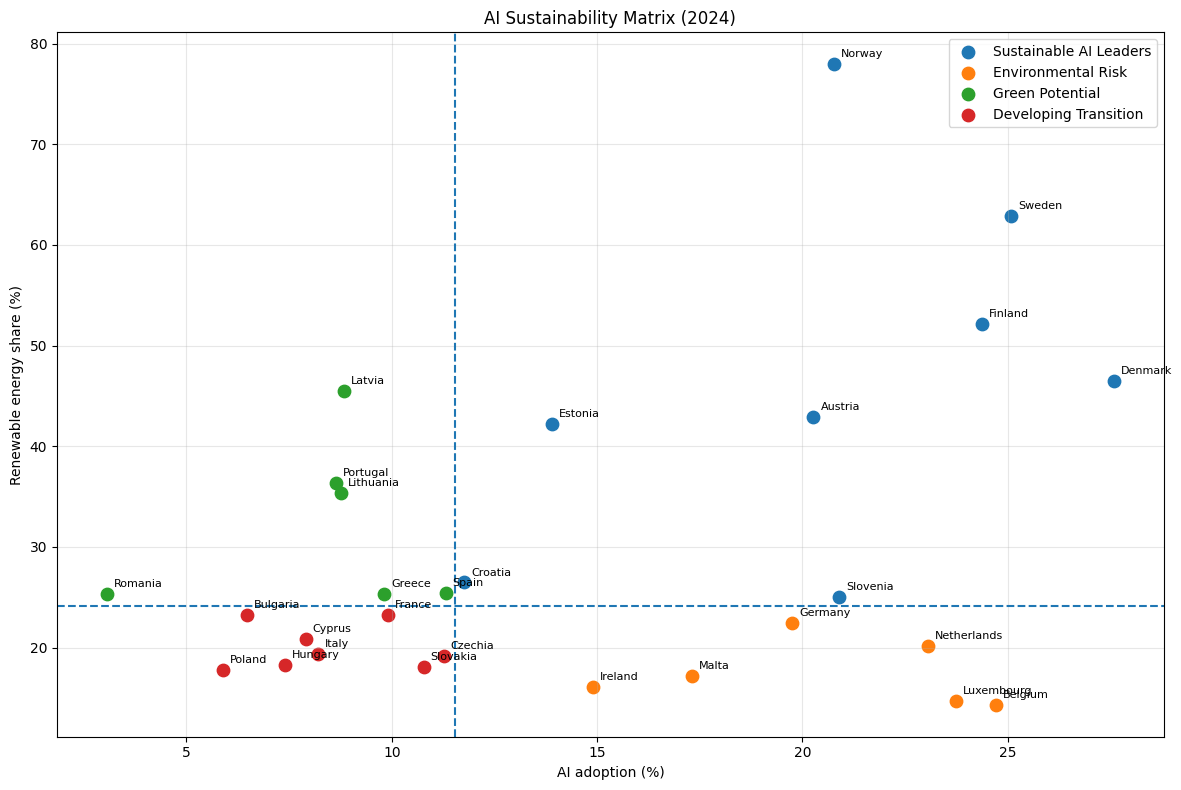

In [88]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))

category_order = [
    "Sustainable AI Leaders",
    "Environmental Risk",
    "Green Potential",
    "Developing Transition"
]

# Plot one group at a time so the legend shows the categories
for category in category_order:
    subset = matrix_df[
        matrix_df["sustainability_category"] == category
    ]

    plt.scatter(
        subset["ai_adoption_pct"],
        subset["renewable_energy_share"],
        s=80,
        label=category
    )

# Add median lines to create the four quadrants
plt.axvline(ai_median, linestyle="--")
plt.axhline(renewable_median, linestyle="--")

# Add country labels using country codes to avoid clutter
for _, row in matrix_df.iterrows():
    plt.annotate(
        row["country_name"],
        (row["ai_adoption_pct"], row["renewable_energy_share"]),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=8
    )

plt.title(f"AI Sustainability Matrix ({latest_complete_year})")
plt.xlabel("AI adoption (%)")
plt.ylabel("Renewable energy share (%)")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [87]:
category_summary = (
    matrix_df
    .groupby("sustainability_category", as_index=False)
    .agg(
        number_of_countries=("geo", "count"),
        average_ai_adoption=("ai_adoption_pct", "mean"),
        average_renewable_share=("renewable_energy_share", "mean"),
        average_co2_emissions=("emissions", "mean")
    )
)

category_summary = category_summary.sort_values(
    "number_of_countries",
    ascending=False
)

print(category_summary)

  sustainability_category  number_of_countries  average_ai_adoption  \
0   Developing Transition                    8             8.478750   
3  Sustainable AI Leaders                    8            20.577500   
1      Environmental Risk                    6            20.575000   
2         Green Potential                    6             8.401667   

   average_renewable_share  average_co2_emissions  
0                20.000625           17323.039484  
3                47.003000            3278.560285  
1                17.501000           19997.374063  
2                32.236833            6461.648527  


In [90]:
%pip install jinja2

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


You should consider upgrading via the 'c:\Program Files\Python39\python.exe -m pip install --upgrade pip' command.


In [91]:
from IPython.display import display

# Put categories in a logical presentation order
category_order = [
    "Sustainable AI Leaders",
    "Environmental Risk",
    "Green Potential",
    "Developing Transition"
]

heatmap_table = (
    category_summary
    .set_index("sustainability_category")
    .reindex(category_order)
)

# Display a colour-coded heatmap-style table
display(
    heatmap_table.style
    .format({
        "number_of_countries": "{:.0f}",
        "average_ai_adoption": "{:.2f}%",
        "average_renewable_share": "{:.2f}%",
        "average_co2_emissions": "{:,.0f}"
    })
    .background_gradient(
        cmap="Blues",
        subset=["number_of_countries", "average_ai_adoption"]
    )
    .background_gradient(
        cmap="YlGn",
        subset=["average_renewable_share"]
    )
    .background_gradient(
        cmap="RdYlGn_r",
        subset=["average_co2_emissions"]
    )
    .set_caption(
        "Sustainability Matrix Summary — greener CO₂ cells represent lower emissions"
    )
)

,number_of_countries,average_ai_adoption,average_renewable_share,average_co2_emissions
sustainability_category,,,,
Sustainable AI Leaders,8,20.58%,47.00%,"3,279"
Environmental Risk,6,20.57%,17.50%,"19,997"
Green Potential,6,8.40%,32.24%,"6,462"
Developing Transition,8,8.48%,20.00%,"17,323"


The heatmap shows that countries with similar AI-adoption levels can have very different environmental outcomes. In the AI-adoption column, both Sustainable AI Leaders and Environmental Risk countries are dark blue, showing similarly high adoption.

However, Sustainable AI Leaders are dark green in the renewable-energy column and green in the CO₂ column, indicating higher renewable-energy shares and lower emissions. Environmental Risk countries are pale yellow for renewables and red for CO₂ emissions, showing lower renewable-energy shares and the highest emissions.

Overall, the colour pattern suggests that high AI adoption is more sustainable when it is supported by cleaner electricity sources.